<a href="https://colab.research.google.com/github/JyoshanaviGudla-5/SCT_DS_3/blob/main/Task3_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank-additional-full.csv to bank-additional-full.csv


In [2]:
!ls


bank-additional-full.csv  sample_data


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Step 1: Load the data
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Step 2: Check NaN and remove them
print("Before removing NaN, rows:", len(df))
df = df.dropna(subset=['y'])
print("After removing NaN, rows:", len(df))

# Step 3: Convert yes=1, no=0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Step 4: Convert all text columns to numbers
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 5: Split data
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train Decision Tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Step 7: Test and print results
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\nAccuracy score:", round(accuracy * 100, 2), "%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Before removing NaN, rows: 41188
After removing NaN, rows: 41188

Accuracy score: 91.24 %

Confusion Matrix:
[[7052  251]
 [ 471  464]]


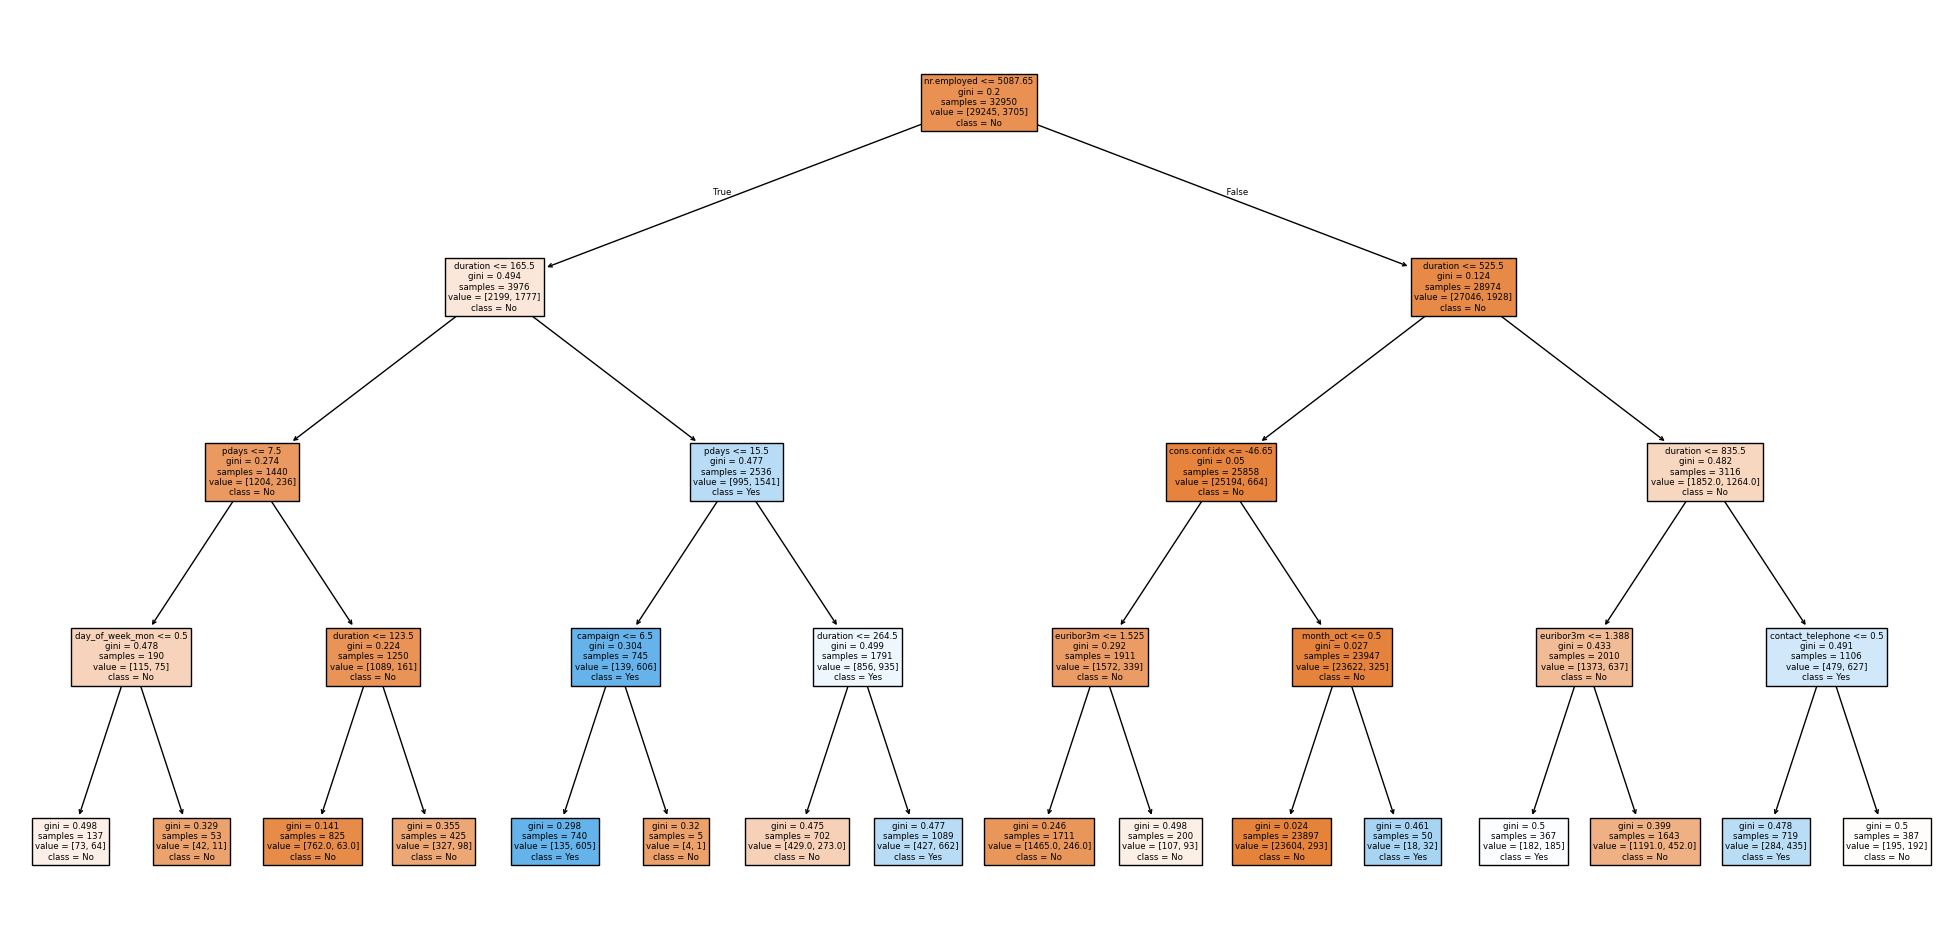

In [5]:
plt.figure(figsize=(25,12))
plot_tree(model,
          feature_names=X.columns,
          class_names=['No', 'Yes'],
          filled=True,
          max_depth=4)
plt.show()